In [1]:
import os
import sys
sys.path.append(os.path.join(".."))
import src.utils.utils as utils
import src.models.data_prep as data_prep
import src.models.inference_models as inference_models
import src.utils.plotting as plotting
import healpy as hp
import numpy as np

import jax
import jax.numpy as jnp
import jax.random as random
import jax.scipy.special as jsp

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import norm  # if not already imported
%matplotlib inline
#print('JAX version:', jax.__version__)
#print('JAX backend:', jax.lib.xla_bridge.get_backend().platform)


# Set a random seed for reproducibility
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"  # Use platform-specific memory allocator
jax.config.update("jax_platform_name", "cpu")  # Use CPU as the platform
#jax.config.update("jax_platform_name", "gpu")  # Use GPU as the platform

In [11]:
result_100 = np.load("/Users/r.kanaki/code/spatial_selection_photo_z/output/multiple_redshift_bins_results/spatial_result_100.npz", allow_pickle=True)
print(result_100.files)

plot_output_dir = "/Users/r.kanaki/code/spatial_selection_photo_z/plots/multiple_redshift_bins/"

# Load the data
config_path = "/Users/r.kanaki/code/spatial_selection_photo_z/configs/evaluation_spatial_selection.yml"
config = utils.read_yaml_config(config_path)

# Read the catalog
catalog_path = config["catalog_params"]["catalog_path"]
catalog = utils.read_catalog(catalog_path, config["catalog_params"]["catalog_dtype"])

['mean_posterior', 'mean_alpha', 'mean_hists', 'mean_hists_noisy', 'grid', 'sample_num', 'posterior_means_all', 'hists_all', 'hists_noisy_all', 'lambdas_all', 'alpha_final_all', 'est_z_all', 'z_noisy_all', 'z_true_all', 'est_z_mean_all', 'z_noisy_mean_all', 'z_true_mean_all']
Total system memory: 16384.00 MB
[read_catalog] Memory before execution: 2526.44 MB
[read_catalog] Memory after execution: 3276.44 MB
[read_catalog] Memory after garbage collection: 3276.44 MB


In [12]:
# Extract data preparation parameters
data_prep_params = config["data_prep_params"]

# Preprocess the data
data_prep_params = config["data_prep_params"]
magnitude_realization = data_prep_params["magnitude_realization"]
magnitude_error = data_prep_params["magnitude_error_realization"]
abs_mag = data_prep_params["abs_mag"]
sed_type = data_prep_params["sed_type"]

# Get the pixel indices
nside = data_prep_params["nside"]
ra_col = data_prep_params["ra_col"]
dec_col = data_prep_params["dec_col"]

# Create the healpix map
data =catalog[data_prep.ra_dec_mask(catalog, data_prep_params['ra_col'], data_prep_params['dec_col'])]
data_magcut = data_prep.magcut_i_band(data, magnitude_realization[2], data_prep_params['magcut_i_band'])
density_map, data_updated = data_prep.create_healpix_map(data_magcut, nside, ra_col, dec_col, edge_cut=True)
pixel_indices = data_updated["pixel_index"].values
pixel_indices = jnp.array(pixel_indices)

plot_output_dir = '/Users/r.kanaki/code/spatial_selection_photo_z/plots/paper/section_4_1_micecat1/'

magnitude cut mask: i_des_realization < 23.5


In [13]:
print(result_100.files)
print(result_100['z_true_all'].shape)
print(pixel_indices.shape)

z_true = result_100["z_true_all"]
pix = np.array(pixel_indices)  # jnp.array -> np.array

# Unique pixel indices and their inverse mapping
unique_pix, inv = np.unique(pix, return_inverse=True)
# unique_pix.shape -> (1380,)
# inv.shape        -> (1513930,) each entry maps to unique_pix

# Sum and count per unique pixel
sum_z   = np.bincount(inv, weights=z_true)
count_z = np.bincount(inv)

mean_z_per_unique_pixel = sum_z / count_z

print(unique_pix.shape)             
print(mean_z_per_unique_pixel.shape)  # (1380,)

['mean_posterior', 'mean_alpha', 'mean_hists', 'mean_hists_noisy', 'grid', 'sample_num', 'posterior_means_all', 'hists_all', 'hists_noisy_all', 'lambdas_all', 'alpha_final_all', 'est_z_all', 'z_noisy_all', 'z_true_all', 'est_z_mean_all', 'z_noisy_mean_all', 'z_true_mean_all']
(1513930,)
(1513930,)
(1380,)
(1380,)


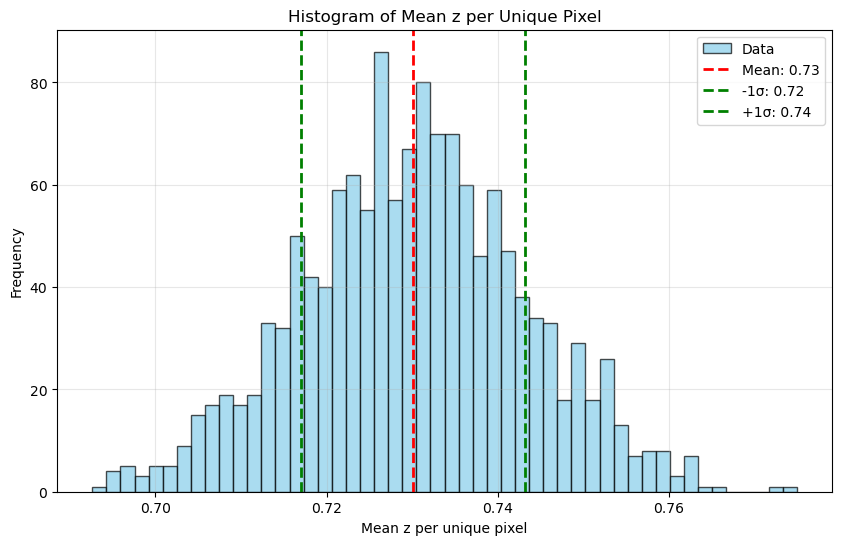

In [14]:
# Calculate mean and standard deviation
mean_value = np.mean(mean_z_per_unique_pixel)
std_dev = np.std(mean_z_per_unique_pixel)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(mean_z_per_unique_pixel, bins=50, color='skyblue', edgecolor='black', alpha=0.7, label='Data')

# Add mean and ±1 sigma lines
plt.axvline(mean_value, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_value:.2f}')
plt.axvline(mean_value - std_dev, color='green', linestyle='--', linewidth=2, label=f'-1σ: {mean_value - std_dev:.2f}')
plt.axvline(mean_value + std_dev, color='green', linestyle='--', linewidth=2, label=f'+1σ: {mean_value + std_dev:.2f}')

# Add labels and legend
plt.xlabel('Mean z per unique pixel')
plt.ylabel('Frequency')
plt.title('Histogram of Mean z per Unique Pixel')
plt.legend()
plt.grid(alpha=0.3)

# Show plot
plt.show()

In [15]:
def get_mu_sigma_from_result(result, N_real=100):
    """
    Given spatial inference result dict, compute mu and sigma^2
    of the lognormal prior via Gamma-Dirichlet sampling + EM.

    Parameters
    ----------
    result : dict
        Output from SpatialRedshiftInference.run_inference()
    N_real : int
        Number of Gamma/Dirichlet samples per pixel.

    Returns
    -------
    mu : ndarray, shape (N_z,)
    sigma2 : ndarray, shape (N_z,)
    N_tot : ndarray, shape (N_pix,)
        Estimated total number of galaxies per pixel.
    """

    # --- Extract needed arrays ---
    mean_alpha_all = result["alpha_final_all"]       # (N_pix, N_z)
    lambda_all = result["lambdas_all"]               # (N_pix, N_z)
    posterior_means_all = result["posterior_means_all"]  # (N_pix, N_z)

    # --- Compute N_tot per pixel ---
    N_tot = lambda_all / posterior_means_all         # (N_pix, N_z)

    # --- Dimensions ---
    N_pix, N_z = mean_alpha_all.shape

    # --- Gamma samples for pi ---
    gamma_samples = np.random.gamma(
        shape=mean_alpha_all[:, None, :],   # (N_pix, 1, N_z)
        scale=1.0,
        size=(N_pix, N_real, N_z)           # (N_pix, N_real, N_z)
    )

    # Normalize → Dirichlet samples (pi)
    pi_samples = gamma_samples / gamma_samples.sum(axis=-1, keepdims=True)

    # --- Lambda samples ---
    lambda_samples = pi_samples * N_tot[:, None, :]   # (N_pix, N_real, N_z)

    # --- EM lognormal update ---
    log_lambda = np.log(lambda_samples)

    mu = log_lambda.mean(axis=(0, 1))                 # (N_z,)
    sigma2 = log_lambda.var(axis=(0, 1), ddof=0)      # (N_z,)

    return mu, sigma2, N_tot

mu_100, sigma2_100, N_tot_100 = get_mu_sigma_from_result(result_100, N_real=100)

In [16]:
key_seed = 42
sample_num = 10000
key = random.PRNGKey(key_seed)
sample_lambda =np.random.lognormal(
        mean=mu_100,
        sigma=jnp.sqrt(sigma2_100),
        size=(sample_num, len(mu_100))
)
sample_pz = sample_lambda/jnp.sum(sample_lambda, axis=1, keepdims=True)
sample_pz = jnp.array(sample_pz) 
grid = result_100['grid']
# Bin centres for redshift bins
z_centers = 0.5 * (grid[:-1] + grid[1:])    # shape (N_z,)

# Ensure NumPy array
sample_pz_np = np.asarray(sample_pz)        # (sample_num, N_z)

# Posterior samples of the *mean redshift* μ = Σ z * p(z)
sample_mean_z = sample_pz_np @ z_centers    # shape (sample_num,)

print(sample_mean_z)

[0.7296386  0.74908674 0.72942454 ... 0.730594   0.7216674  0.73758286]


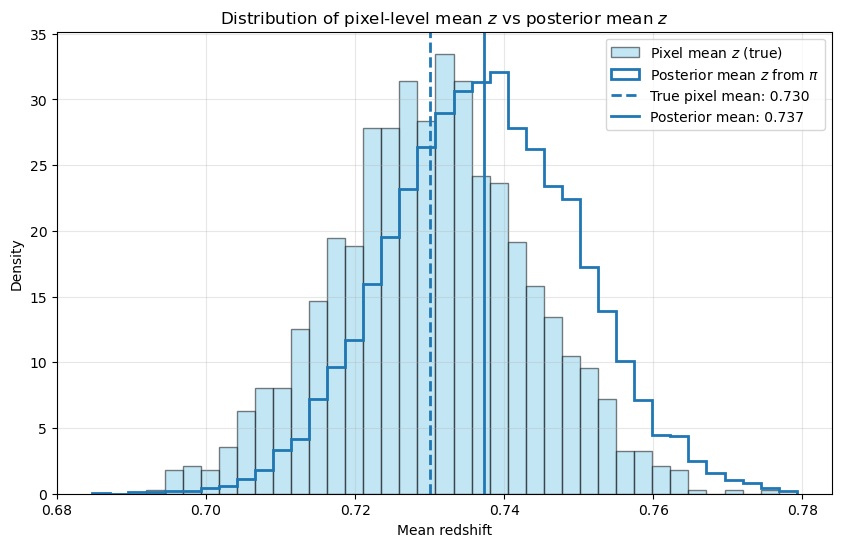

In [17]:
plt.figure(figsize=(10, 6))

# Common binning for fair comparison
z_min = min(mean_z_per_unique_pixel.min(), sample_mean_z.min())
z_max = max(mean_z_per_unique_pixel.max(), sample_mean_z.max())
bins = np.linspace(z_min, z_max, 40)

# Histogram of true pixel-level mean z
plt.hist(
    mean_z_per_unique_pixel,
    bins=bins,
    density=True,
    alpha=0.5,
    color='skyblue',
    edgecolor='black',
    label='Pixel mean $z$ (true)'
)

# Histogram of posterior mean z from p(z)
plt.hist(
    sample_mean_z,
    bins=bins,
    density=True,
    histtype='step',
    linewidth=2,
    label='Posterior mean $z$ from $\\pi$'
)

# Optional: vertical lines for means
plt.axvline(mean_z_per_unique_pixel.mean(), linestyle='--', linewidth=2,
            label=f'True pixel mean: {mean_z_per_unique_pixel.mean():.3f}')
plt.axvline(sample_mean_z.mean(), linestyle='-', linewidth=2,
            label=f'Posterior mean: {sample_mean_z.mean():.3f}')

plt.xlabel('Mean redshift')
plt.ylabel('Density')
plt.title('Distribution of pixel-level mean $z$ vs posterior mean $z$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
# Calculate standard deviations
std_sample_mean_z = np.std(sample_mean_z)
std_mean_z_per_unique_pixel = np.std(mean_z_per_unique_pixel)

# Print the results
print(f"Standard deviation of posterior mean redshift: {std_sample_mean_z:.6f}")
print(f"Standard deviation of true pixel-level mean redshift: {std_mean_z_per_unique_pixel:.6f}")

# Compare the widths
if std_sample_mean_z < std_mean_z_per_unique_pixel:
    print("The posterior mean redshift has a narrower width compared to the true pixel-level mean redshift.")
else:
    print("The posterior mean redshift has a wider or equal width compared to the true pixel-level mean redshift.")

Standard deviation of posterior mean redshift: 0.012676
Standard deviation of true pixel-level mean redshift: 0.013099
The posterior mean redshift has a narrower width compared to the true pixel-level mean redshift.
